# Proyecto 5

In [207]:
## Importamos librerías y archivo de funciones

In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import functions as f
import statsmodels.api as sm
from scipy.stats.contingency import association
from scipy.stats import mannwhitneyu
from scipy import stats
from scipy.stats import ttest_ind


##  DF  PERFILES (df_final_demo)

In [209]:
df_final = pd.read_csv('data/datos_limpios.csv') 

# ANÁLISIS

In [210]:
## Agrupamos por test o control y por procesos, para contar cuantas veces se hicieron las etapas 
df_final.groupby('tipo')["paso"].value_counts()

tipo     paso   
Control  start      45366
         step_1     29535
         step_2     25766
         step_3     22497
         confirm    17330
Test     start      55753
         step_1     38651
         step_2     30888
         step_3     25755
         confirm    25594
Name: count, dtype: int64

In [211]:
## Ahora hacemos un conteo de los procesos realizados por cada cliente. 
df_final.groupby(['tipo',"paso"])["client_id"].nunique()

tipo     paso   
Control  confirm    15429
         start      23392
         step_1     20147
         step_2     18645
         step_3     17417
Test     confirm    18682
         start      26672
         step_1     24260
         step_2     22252
         step_3     20876
Name: client_id, dtype: int64

In [212]:
## Hacemos la tabla de contingencia para analizar las variables categóricas que son tipo y paso
clientes_proceso = pd.crosstab(df_final['tipo'], df_final['paso'])
clientes_proceso

paso,confirm,start,step_1,step_2,step_3
tipo,,,,,
Control,17330,45366,29535,25766,22497
Test,25594,55753,38651,30888,25755


In [213]:
## Ordenamos para que sea más claro
orden_logico = ['start', 'step_1', 'step_2', 'step_3', 'confirm']
df_final['paso']= pd.Categorical(df_final['paso'], categories=orden_logico, ordered=True)

In [214]:
clientes_proceso

paso,confirm,start,step_1,step_2,step_3
tipo,,,,,
Control,17330,45366,29535,25766,22497
Test,25594,55753,38651,30888,25755


<Axes: xlabel='tipo', ylabel='count'>

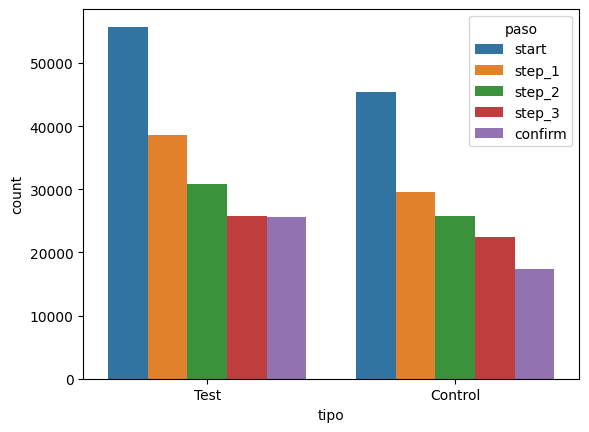

In [215]:
## Hacemos una visualización de gráfica de barras agrupadas para tener una visión más clara del conteo
sns.countplot(data=df_final, x='tipo', hue='paso')

<Axes: xlabel='paso', ylabel='tipo'>

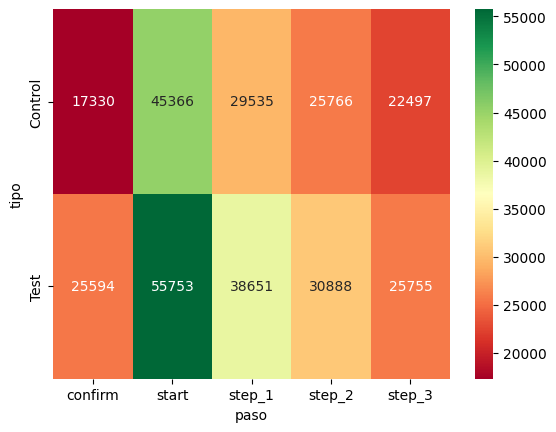

In [216]:
## Hacemos un heatmap para ver las correlaciones (si es que las hay) entre todas ambas variables y tener una visión más global. 
sns.heatmap(clientes_proceso, annot=True, cmap="RdYlGn", fmt="d")

### ¿CAMBIA EL PERFIL ENTRE GRUPO TEST Y GRUPO CONTROL?

In [217]:
df_final

,client_id,años_fidelizacion,meses_fidelizacion,edad,genero,cantidad_cuentas,saldo_total_distribuido,llamadas_ultimos_6meses,log_in_ultimos_6meses,tipo,visitor_id,visit_id,paso,fecha_y_hora,fecha,hora,grupo_hora
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test,427070339_1413275162,228976764_46825473280_96584,confirm,2017-04-02 11:51:13,2017-04-02,11:51:13,Mañana(6-12)
1,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test,427070339_1413275162,228976764_46825473280_96584,confirm,2017-04-02 11:47:50,2017-04-02,11:47:50,Mañana(6-12)
2,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test,427070339_1413275162,228976764_46825473280_96584,confirm,2017-04-02 11:46:45,2017-04-02,11:46:45,Mañana(6-12)
3,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test,427070339_1413275162,228976764_46825473280_96584,step_3,2017-04-02 11:23:08,2017-04-02,11:23:08,Mañana(6-12)
4,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0,Test,427070339_1413275162,228976764_46825473280_96584,step_2,2017-04-02 11:22:24,2017-04-02,11:22:24,Mañana(6-12)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317130,7468138,18.0,222.0,61.0,F,3.0,209278.15,0.0,3.0,Test,317123960_46820919455,769876461_30381166055_830233,step_2,2017-03-30 23:59:15,2017-03-30,23:59:15,Tarde(18-24)
317131,7468138,18.0,222.0,61.0,F,3.0,209278.15,0.0,3.0,Test,317123960_46820919455,769876461_30381166055_830233,step_1,2017-03-30 23:58:51,2017-03-30,23:58:51,Tarde(18-24)
317132,7468138,18.0,222.0,61.0,F,3.0,209278.15,0.0,3.0,Test,317123960_46820919455,769876461_30381166055_830233,start,2017-03-30 23:58:40,2017-03-30,23:58:40,Tarde(18-24)
317133,7468138,18.0,222.0,61.0,F,3.0,209278.15,0.0,3.0,Test,317123960_46820919455,769876461_30381166055_830233,start,2017-03-30 23:55:11,2017-03-30,23:55:11,Tarde(18-24)


In [218]:
## Creamos dos dataframes para comparar el perfil de los clientes que utilizan el proceso en línea (Test) con los que no lo utilizan (Control)
df_control= df_final[df_final["tipo"]=="Control"]
df_test= df_final[df_final["tipo"]=="Test"]

In [219]:
perfil_control= df_control.groupby("genero").agg({
    "años_fidelizacion":"mean",
    "log_in_ultimos_6meses":"mean",
    "edad":"mean",
    "client_id":"nunique"
   }).rename(columns={"client_id":"total_clientes"})

In [220]:
perfil_test=df_test.groupby("genero").agg({
    "años_fidelizacion":"mean",
    "log_in_ultimos_6meses":"mean",
    "edad":"mean",
    "client_id":"nunique"
   }).rename(columns={"client_id":"total_clientes"})

In [221]:

perfil_control

,años_fidelizacion,log_in_ultimos_6meses,edad,total_clientes
genero,,,,
F,14.927018,6.011559,51.440712,7543
M,15.131878,6.647432,50.727628,7970
U,6.722346,6.236219,42.983649,8014


In [222]:
perfil_test

,años_fidelizacion,log_in_ultimos_6meses,edad,total_clientes
genero,,,,
F,14.89809,5.997714,51.775104,8716
M,14.96323,6.586982,50.730030,8977
U,6.72597,6.136745,43.711555,9266
X,10.25000,7.125000,34.750000,2


In [223]:
perfil_control["grupo"]="Control"
perfil_test["grupo"]="Test"

In [224]:
df_grupos = pd.concat([perfil_control.reset_index(), perfil_test.reset_index()])

In [225]:
df_plot = df_grupos.melt(id_vars=['genero', 'grupo'], var_name='Metrica', value_name='Valor')

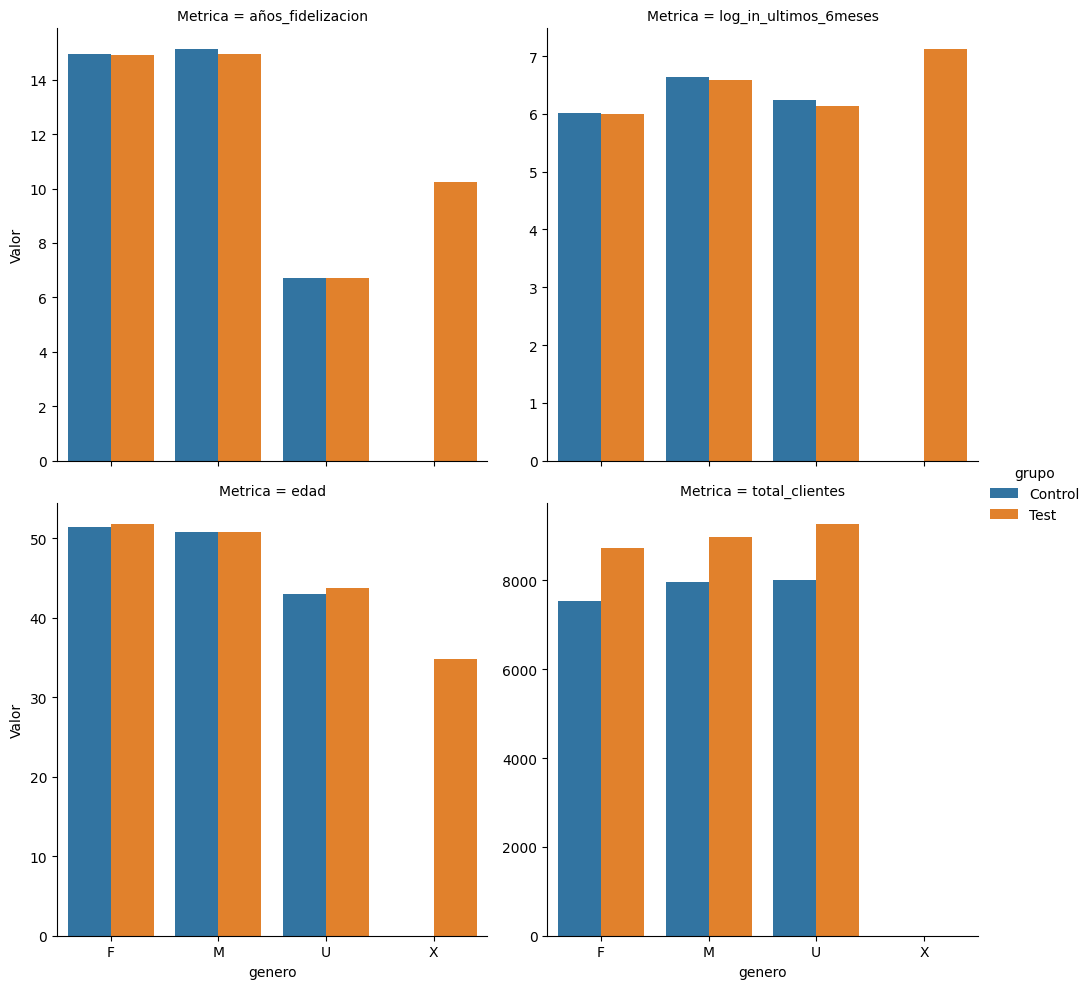

In [226]:
# Crear un gráfico facetado
g = sns.catplot(
    data=df_plot, x='genero', y='Valor', hue='grupo', 
    col='Metrica', kind='bar', col_wrap=2, sharey=False)

### Tasa de finalización

##### Comprobación valores: Calculamos el metodo de Cramer que va entre 0 y 1, donde 0 que no hay relación y 1 hay relación. 

In [227]:
# Veremos los datos de nuestra tasa de finalización
tasa_finalizacion=clientes_proceso[['start', 'confirm']]

In [228]:
association(tasa_finalizacion, method="cramer")

0.041423808679319225

El valor V de Cramér de 0,041 sugiere una asociación débil entre ambas variables.

Para que un proceso pase por el estado de finalización, debe partir y finalizar el mismo día. 

In [229]:
# Agrupamos los pasos de cada cliente por día y tipo. 
pasos_por_dia= df_final.groupby(['client_id', 'fecha', 'tipo'])['paso'].unique().reset_index()

In [230]:
pasos_por_dia.head()

,client_id,fecha,tipo,paso
0,555,2017-04-15,Test,"['confirm', 'step_3', 'step_2', 'step_1', 'sta..."
1,647,2017-04-12,Test,"['confirm', 'step_3', 'step_2', 'step_1', 'sta..."
2,934,2017-04-18,Test,"['start'] Categories (5, object): ['start' < '..."
3,1028,2017-04-08,Control,"['step_1', 'step_2', 'step_3', 'start'] Catego..."
4,1104,2017-06-12,Control,"['start'] Categories (5, object): ['start' < '..."


In [231]:
# Contamos como iniciados todos aquellos que tienen el paso start y lo marcamos como True
pasos_por_dia['hizo_start'] = pasos_por_dia['paso'].apply(lambda x: 'start' in x)


In [232]:
# Contamos cuando hizo confirm y lo marcamos como True
pasos_por_dia['hizo_confirm'] = pasos_por_dia['paso'].apply(lambda x: 'confirm' in x)

In [233]:
pasos_por_dia.head()

,client_id,fecha,tipo,paso,hizo_start,hizo_confirm
0,555,2017-04-15,Test,"['confirm', 'step_3', 'step_2', 'step_1', 'sta...",True,True
1,647,2017-04-12,Test,"['confirm', 'step_3', 'step_2', 'step_1', 'sta...",True,True
2,934,2017-04-18,Test,"['start'] Categories (5, object): ['start' < '...",True,False
3,1028,2017-04-08,Control,"['step_1', 'step_2', 'step_3', 'start'] Catego...",True,False
4,1104,2017-06-12,Control,"['start'] Categories (5, object): ['start' < '...",True,False


In [234]:
# Filtramos y solo trabajamos con los que hicieron start
pasos_por_dia[pasos_por_dia['hizo_start'] == True]

,client_id,fecha,tipo,paso,hizo_start,hizo_confirm
0,555,2017-04-15,Test,"['confirm', 'step_3', 'step_2', 'step_1', 'sta...",True,True
1,647,2017-04-12,Test,"['confirm', 'step_3', 'step_2', 'step_1', 'sta...",True,True
2,934,2017-04-18,Test,"['start'] Categories (5, object): ['start' < '...",True,False
3,1028,2017-04-08,Control,"['step_1', 'step_2', 'step_3', 'start'] Catego...",True,False
4,1104,2017-06-12,Control,"['start'] Categories (5, object): ['start' < '...",True,False
...,...,...,...,...,...,...
66336,9999626,2017-05-14,Test,"['step_1', 'start'] Categories (5, object): ['...",True,False
66337,9999729,2017-04-05,Test,"['step_1', 'start'] Categories (5, object): ['...",True,False
66338,9999729,2017-04-20,Test,"['start', 'step_2', 'step_1'] Categories (5, o...",True,False
66339,9999729,2017-05-08,Test,"['confirm', 'step_3', 'step_2', 'step_1', 'sta...",True,True


In [235]:
# Haremos una columna que indique si el usuario completo el formulario en el mismo dia que inicio
pasos_por_dia['completo_mismo_dia'] = pasos_por_dia['hizo_confirm']

In [236]:
pasos_por_dia.head()

,client_id,fecha,tipo,paso,hizo_start,hizo_confirm,completo_mismo_dia
0,555,2017-04-15,Test,"['confirm', 'step_3', 'step_2', 'step_1', 'sta...",True,True,True
1,647,2017-04-12,Test,"['confirm', 'step_3', 'step_2', 'step_1', 'sta...",True,True,True
2,934,2017-04-18,Test,"['start'] Categories (5, object): ['start' < '...",True,False,False
3,1028,2017-04-08,Control,"['step_1', 'step_2', 'step_3', 'start'] Catego...",True,False,False
4,1104,2017-06-12,Control,"['start'] Categories (5, object): ['start' < '...",True,False,False


In [237]:
# Determinamos las metricas para ambos grupos

resultado = pasos_por_dia.groupby('tipo').agg(
    total_inicios_unicos=('client_id', 'count'),
    completados_mismo_dia=('completo_mismo_dia', 'sum')
).reset_index()

In [238]:
# Calculé la tasa de finalización
resultado['tasa_finalizacion'] = (resultado['completados_mismo_dia'] / resultado['total_inicios_unicos']) * 100

tabla_final = resultado.set_index('tipo')
tabla_final


,total_inicios_unicos,completados_mismo_dia,tasa_finalizacion
tipo,,,
Control,30795,16053,52.128592
Test,35546,21612,60.800090


Veamos algunos ejemplos de como se comportan algunos clientes 

In [239]:
filas_cliente = pasos_por_dia[pasos_por_dia['client_id'] == 555]
filas_cliente

,client_id,fecha,tipo,paso,hizo_start,hizo_confirm,completo_mismo_dia
0,555,2017-04-15,Test,"['confirm', 'step_3', 'step_2', 'step_1', 'sta...",True,True,True


In [240]:
df_final[df_final["client_id"]==555]

,client_id,años_fidelizacion,meses_fidelizacion,edad,genero,cantidad_cuentas,saldo_total_distribuido,llamadas_ultimos_6meses,log_in_ultimos_6meses,tipo,visitor_id,visit_id,paso,fecha_y_hora,fecha,hora,grupo_hora
252090,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,2017-04-15,13:00:34,Mediodía(12-18)
252091,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,2017-04-15,13:00:14,Mediodía(12-18)
252092,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,2017-04-15,12:58:35,Mañana(6-12)
252093,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,2017-04-15,12:58:03,Mañana(6-12)
252094,555,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,2017-04-15,12:57:56,Mañana(6-12)


In [241]:
pasos_por_dia[pasos_por_dia["client_id"]==9999729]

,client_id,fecha,tipo,paso,hizo_start,hizo_confirm,completo_mismo_dia
66337,9999729,2017-04-05,Test,"['step_1', 'start'] Categories (5, object): ['...",True,False,False
66338,9999729,2017-04-20,Test,"['start', 'step_2', 'step_1'] Categories (5, o...",True,False,False
66339,9999729,2017-05-08,Test,"['confirm', 'step_3', 'step_2', 'step_1', 'sta...",True,True,True


In [242]:
filas_cliente2= df_final[df_final['client_id'] ==9999729]
filas_cliente2

,client_id,años_fidelizacion,meses_fidelizacion,edad,genero,cantidad_cuentas,saldo_total_distribuido,llamadas_ultimos_6meses,log_in_ultimos_6meses,tipo,visitor_id,visit_id,paso,fecha_y_hora,fecha,hora,grupo_hora
306144,9999729,10.0,124.0,31.0,F,3.0,107059.74,6.0,9.0,Test,604429154_69247391147,99583652_41711450505_426179,step_1,2017-04-05 13:41:04,2017-04-05,13:41:04,Mediodía(12-18)
306145,9999729,10.0,124.0,31.0,F,3.0,107059.74,6.0,9.0,Test,604429154_69247391147,99583652_41711450505_426179,start,2017-04-05 13:40:49,2017-04-05,13:40:49,Mediodía(12-18)
306146,9999729,10.0,124.0,31.0,F,3.0,107059.74,6.0,9.0,Test,843385170_36953471821,493310979_9209676464_421146,start,2017-04-20 14:28:57,2017-04-20,14:28:57,Mediodía(12-18)
306147,9999729,10.0,124.0,31.0,F,3.0,107059.74,6.0,9.0,Test,843385170_36953471821,493310979_9209676464_421146,step_2,2017-04-20 14:27:36,2017-04-20,14:27:36,Mediodía(12-18)
306148,9999729,10.0,124.0,31.0,F,3.0,107059.74,6.0,9.0,Test,843385170_36953471821,493310979_9209676464_421146,step_1,2017-04-20 14:22:49,2017-04-20,14:22:49,Mediodía(12-18)
306149,9999729,10.0,124.0,31.0,F,3.0,107059.74,6.0,9.0,Test,843385170_36953471821,493310979_9209676464_421146,start,2017-04-20 14:21:27,2017-04-20,14:21:27,Mediodía(12-18)
306150,9999729,10.0,124.0,31.0,F,3.0,107059.74,6.0,9.0,Test,834634258_21862004160,870243567_56915814033_814203,confirm,2017-05-08 16:09:40,2017-05-08,16:09:40,Mediodía(12-18)
306151,9999729,10.0,124.0,31.0,F,3.0,107059.74,6.0,9.0,Test,834634258_21862004160,870243567_56915814033_814203,step_3,2017-05-08 16:09:19,2017-05-08,16:09:19,Mediodía(12-18)
306152,9999729,10.0,124.0,31.0,F,3.0,107059.74,6.0,9.0,Test,834634258_21862004160,870243567_56915814033_814203,step_2,2017-05-08 16:08:40,2017-05-08,16:08:40,Mediodía(12-18)
306153,9999729,10.0,124.0,31.0,F,3.0,107059.74,6.0,9.0,Test,834634258_21862004160,870243567_56915814033_814203,step_1,2017-05-08 16:08:30,2017-05-08,16:08:30,Mediodía(12-18)


Algunas visualizaciones que se pueden hacer con los datos:

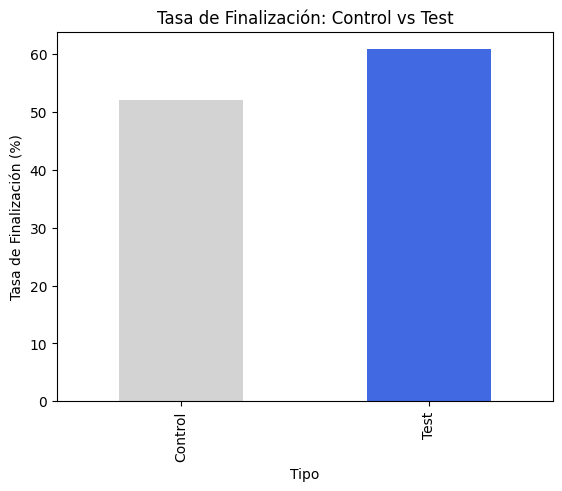

In [243]:
tabla_final["tasa_finalizacion"].plot(kind='bar', color=['lightgrey', 'royalblue'])
plt.title('Tasa de Finalización: Control vs Test')
plt.ylabel('Tasa de Finalización (%)')
plt.xlabel('Tipo')
plt.show()

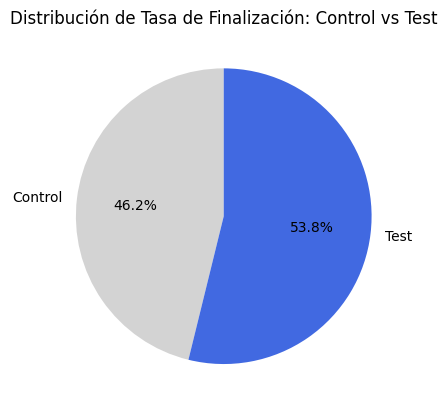

In [244]:
tabla_final["tasa_finalizacion"].plot(
    kind='pie', 
    colors=['lightgrey', 'royalblue'], 
    autopct='%1.1f%%', 
    startangle=90,
    ylabel=''
)

plt.title('Distribución de Tasa de Finalización: Control vs Test')
plt.show()

##### Analicemos Cramer en esta tasa de finalización

In [245]:
analisis=tabla_final[["total_inicios_unicos","completados_mismo_dia"]]

In [246]:
association(analisis,method="cramer")

0.036696194326669755

El valor V de Cramér de 0,037 sugiere una asociación débil entre ambas variables.

In [247]:
df_final.columns

Index(['client_id', 'años_fidelizacion', 'meses_fidelizacion', 'edad',
       'genero', 'cantidad_cuentas', 'saldo_total_distribuido',
       'llamadas_ultimos_6meses', 'log_in_ultimos_6meses', 'tipo',
       'visitor_id', 'visit_id', 'paso', 'fecha_y_hora', 'fecha', 'hora',
       'grupo_hora'],
      dtype='object')

### Tiempo dedicado a cada paso

In [248]:
## Quiero asegurar que la columna fecha y hora esté en formato date time
df_final['fecha_y_hora'] = pd.to_datetime(df_final['fecha_y_hora'])

In [249]:
## Quiero ordenar por usuario, el tiempo que ha pasado
df_final = df_final.sort_values(by=['visit_id', 'fecha_y_hora'])

In [250]:
## Agrupamos todas las filas que pertenecen a la misma visita y dentro de esa agrupación, coge la fila y resta la fila justo anterior (que se supone que es otra visita, aunque sea el mismo cliente) 
df_final['tiempo_visita'] = df_final.groupby('visit_id')['fecha_y_hora'].diff()

In [251]:
df_final

,client_id,años_fidelizacion,meses_fidelizacion,edad,genero,cantidad_cuentas,saldo_total_distribuido,llamadas_ultimos_6meses,log_in_ultimos_6meses,tipo,visitor_id,visit_id,paso,fecha_y_hora,fecha,hora,grupo_hora,tiempo_visita
300422,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,2017-04-26,13:22:17,Mediodía(12-18),NaT
300421,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09,2017-04-26,13:23:09,Mediodía(12-18),0 days 00:00:52
76866,7338123,7.0,88.0,23.5,M,2.0,26436.73,6.0,9.0,Test,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:20:56,2017-04-09,16:20:56,Mediodía(12-18),NaT
76865,7338123,7.0,88.0,23.5,M,2.0,26436.73,6.0,9.0,Test,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:12,2017-04-09,16:21:12,Mediodía(12-18),0 days 00:00:16
76864,7338123,7.0,88.0,23.5,M,2.0,26436.73,6.0,9.0,Test,612065484_94198474375,100019538_17884295066_43909,step_2,2017-04-09 16:21:21,2017-04-09,16:21:21,Mediodía(12-18),0 days 00:00:09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196202,6627522,18.0,227.0,58.0,F,2.0,1056775.54,6.0,9.0,Test,730634087_44272418812,999988789_76411676596_272843,start,2017-04-21 23:49:11,2017-04-21,23:49:11,Tarde(18-24),NaT
196201,6627522,18.0,227.0,58.0,F,2.0,1056775.54,6.0,9.0,Test,730634087_44272418812,999988789_76411676596_272843,step_1,2017-04-21 23:49:22,2017-04-21,23:49:22,Tarde(18-24),0 days 00:00:11
196200,6627522,18.0,227.0,58.0,F,2.0,1056775.54,6.0,9.0,Test,730634087_44272418812,999988789_76411676596_272843,step_2,2017-04-21 23:50:16,2017-04-21,23:50:16,Tarde(18-24),0 days 00:00:54
196199,6627522,18.0,227.0,58.0,F,2.0,1056775.54,6.0,9.0,Test,730634087_44272418812,999988789_76411676596_272843,step_1,2017-04-21 23:51:00,2017-04-21,23:51:00,Tarde(18-24),0 days 00:00:44


In [252]:
## Como realmente no podemos calcularlos por días, sino por segundos, buscamos pasarlos a segundos. 

In [253]:
df_final['segundos_visita'] = df_final['tiempo_visita'].dt.total_seconds()

In [254]:
df_final

,client_id,años_fidelizacion,meses_fidelizacion,edad,genero,cantidad_cuentas,saldo_total_distribuido,llamadas_ultimos_6meses,log_in_ultimos_6meses,tipo,visitor_id,visit_id,paso,fecha_y_hora,fecha,hora,grupo_hora,tiempo_visita,segundos_visita
300422,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,2017-04-26,13:22:17,Mediodía(12-18),NaT,NaN
300421,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,451664975_1722933822,100012776_37918976071_457913,confirm,2017-04-26 13:23:09,2017-04-26,13:23:09,Mediodía(12-18),0 days 00:00:52,52.0
76866,7338123,7.0,88.0,23.5,M,2.0,26436.73,6.0,9.0,Test,612065484_94198474375,100019538_17884295066_43909,start,2017-04-09 16:20:56,2017-04-09,16:20:56,Mediodía(12-18),NaT,NaN
76865,7338123,7.0,88.0,23.5,M,2.0,26436.73,6.0,9.0,Test,612065484_94198474375,100019538_17884295066_43909,step_1,2017-04-09 16:21:12,2017-04-09,16:21:12,Mediodía(12-18),0 days 00:00:16,16.0
76864,7338123,7.0,88.0,23.5,M,2.0,26436.73,6.0,9.0,Test,612065484_94198474375,100019538_17884295066_43909,step_2,2017-04-09 16:21:21,2017-04-09,16:21:21,Mediodía(12-18),0 days 00:00:09,9.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196202,6627522,18.0,227.0,58.0,F,2.0,1056775.54,6.0,9.0,Test,730634087_44272418812,999988789_76411676596_272843,start,2017-04-21 23:49:11,2017-04-21,23:49:11,Tarde(18-24),NaT,NaN
196201,6627522,18.0,227.0,58.0,F,2.0,1056775.54,6.0,9.0,Test,730634087_44272418812,999988789_76411676596_272843,step_1,2017-04-21 23:49:22,2017-04-21,23:49:22,Tarde(18-24),0 days 00:00:11,11.0
196200,6627522,18.0,227.0,58.0,F,2.0,1056775.54,6.0,9.0,Test,730634087_44272418812,999988789_76411676596_272843,step_2,2017-04-21 23:50:16,2017-04-21,23:50:16,Tarde(18-24),0 days 00:00:54,54.0
196199,6627522,18.0,227.0,58.0,F,2.0,1056775.54,6.0,9.0,Test,730634087_44272418812,999988789_76411676596_272843,step_1,2017-04-21 23:51:00,2017-04-21,23:51:00,Tarde(18-24),0 days 00:00:44,44.0


In [255]:
## Comprobamos los nulos, como hay muchos nulos
df_final['segundos_visita'].isnull().sum()

np.int64(69185)

In [256]:
## Decidimos imputar valores de 0 porque que no haya diferencia es que no ha habido visita útil
df_final['segundos_visita'] = df_final['segundos_visita'].fillna(0)

In [257]:
duracion_total_pasos = df_final.groupby('paso')['segundos_visita'].agg(['sum', 'mean']).round(2)

/var/folders/bk/hzstscb16rn4p883jsg8t31c0000gn/T/ipykernel_2800/1324079921.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  duracion_total_pasos = df_final.groupby('paso')['segundos_visita'].agg(['sum', 'mean']).round(2)


In [258]:
duracion_total_pasos

,sum,mean
paso,,
start,6075398.0,60.08
step_1,2711761.0,39.77
step_2,2479318.0,43.76
step_3,4583437.0,94.99
confirm,5031860.0,117.23


In [259]:
## El paso 1 (unos 40 segundos) y el dos (unos 43 segundos) son los más rápidos, mientras que en el paso 3 la media es más del doble (un minuto y medio) y ya en la confirmación hay casi 3 minutos de espera, quizá porque haya una revisión del resto de pasos. 

/var/folders/bk/hzstscb16rn4p883jsg8t31c0000gn/T/ipykernel_2800/2688485706.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=duracion_total_pasos.index, y='mean', data=duracion_total_pasos, palette='viridis')


Text(0, 0.5, 'Segundos (Media)')

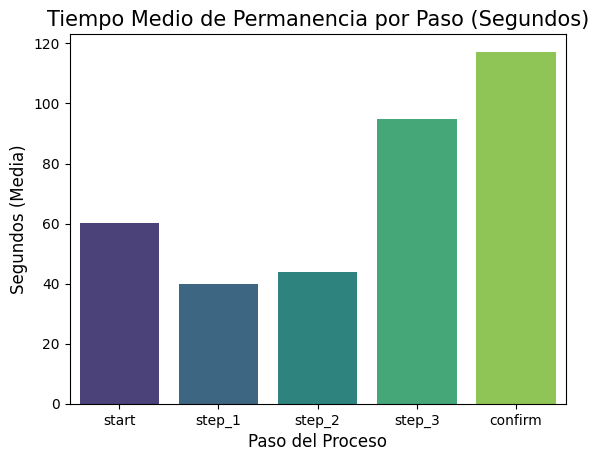

In [260]:
ax = sns.barplot(x=duracion_total_pasos.index, y='mean', data=duracion_total_pasos, palette='viridis')
plt.title('Tiempo Medio de Permanencia por Paso (Segundos)', fontsize=15)
plt.xlabel('Paso del Proceso', fontsize=12)
plt.ylabel('Segundos (Media)', fontsize=12)

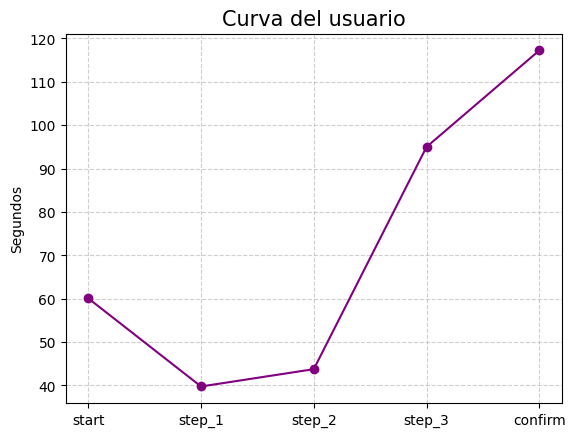

In [261]:
plt.plot(duracion_total_pasos.index, duracion_total_pasos['mean'], marker='o', linestyle='-', color='purple')
plt.title('Curva del usuario', fontsize=15)
plt.ylabel('Segundos')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Tasas de error

In [262]:
df_error=df_final[["client_id","visit_id","fecha_y_hora","paso","tipo"]]

In [263]:
# Pondremos una columna nueva con el orden lógico de los pasos de navegación
orden_pasos = {
    'start': 1,
    'step_1': 2,
    'step_2': 3,
    'step_3': 4,
    'confirm': 5
}

df_error['paso_num'] = df_error['paso'].map(orden_pasos)

/var/folders/bk/hzstscb16rn4p883jsg8t31c0000gn/T/ipykernel_2800/964484900.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_error['paso_num'] = df_error['paso'].map(orden_pasos)


In [264]:
df_error.head(5)

,client_id,visit_id,fecha_y_hora,paso,tipo,paso_num
300422,3561384,100012776_37918976071_457913,2017-04-26 13:22:17,confirm,Test,5
300421,3561384,100012776_37918976071_457913,2017-04-26 13:23:09,confirm,Test,5
76866,7338123,100019538_17884295066_43909,2017-04-09 16:20:56,start,Test,1
76865,7338123,100019538_17884295066_43909,2017-04-09 16:21:12,step_1,Test,2
76864,7338123,100019538_17884295066_43909,2017-04-09 16:21:21,step_2,Test,3


In [265]:
# Haremos el orden cronologico de los pasos de 1 al 5
df_error = df_error.sort_values(['client_id', 'visit_id', 'fecha_y_hora'])

In [266]:
df_error.head(5)

,client_id,visit_id,fecha_y_hora,paso,tipo,paso_num
252094,555,637149525_38041617439_716659,2017-04-15 12:57:56,start,Test,1
252093,555,637149525_38041617439_716659,2017-04-15 12:58:03,step_1,Test,2
252092,555,637149525_38041617439_716659,2017-04-15 12:58:35,step_2,Test,3
252091,555,637149525_38041617439_716659,2017-04-15 13:00:14,step_3,Test,4
252090,555,637149525_38041617439_716659,2017-04-15 13:00:34,confirm,Test,5


In [267]:
# Obtener el paso anterior para cada interacción dentro de la misma visita
df_error['paso_anterior'] = df_error.groupby(['client_id', 'visit_id'])['paso_num'].shift(1)


In [268]:
df_error.head(5)

,client_id,visit_id,fecha_y_hora,paso,tipo,paso_num,paso_anterior
252094,555,637149525_38041617439_716659,2017-04-15 12:57:56,start,Test,1,NaN
252093,555,637149525_38041617439_716659,2017-04-15 12:58:03,step_1,Test,2,1
252092,555,637149525_38041617439_716659,2017-04-15 12:58:35,step_2,Test,3,2
252091,555,637149525_38041617439_716659,2017-04-15 13:00:14,step_3,Test,4,3
252090,555,637149525_38041617439_716659,2017-04-15 13:00:34,confirm,Test,5,4


In [269]:

# Definimos el error: Si el paso actual es menor o igual al anterior 
# (Se usa <= si repetir el mismo paso también se considera error/atascamiento)

df_error['es_error'] = (df_error['paso_num'] <= df_error['paso_anterior'])



In [270]:
df_error.head(5)

,client_id,visit_id,fecha_y_hora,paso,tipo,paso_num,paso_anterior,es_error
252094,555,637149525_38041617439_716659,2017-04-15 12:57:56,start,Test,1,NaN,False
252093,555,637149525_38041617439_716659,2017-04-15 12:58:03,step_1,Test,2,1,False
252092,555,637149525_38041617439_716659,2017-04-15 12:58:35,step_2,Test,3,2,False
252091,555,637149525_38041617439_716659,2017-04-15 13:00:14,step_3,Test,4,3,False
252090,555,637149525_38041617439_716659,2017-04-15 13:00:34,confirm,Test,5,4,False


In [271]:
# Calcular la Tasa de Error por tipo :Test o control

tasa_error = df_error.groupby('tipo').agg(
    total_interacciones=('paso', 'count'),
    cantidad_errores=('es_error', 'sum')
).reset_index()

In [272]:
tasa_error

,tipo,total_interacciones,cantidad_errores
0,Control,140494,23246
1,Test,176641,35239


In [273]:
# Determinamos la tasa de error:
tasa_error['tasa_error'] = (tasa_error['cantidad_errores'] / tasa_error['total_interacciones']) * 100



In [274]:
# La tabla de tasas de error queda así:
tabla_error = tasa_error.set_index('tipo')

In [310]:
tasa_error.round(2)

,tipo,total_interacciones,cantidad_errores,tasa_error
0,Control,140494,23246,16.55
1,Test,176641,35239,19.95


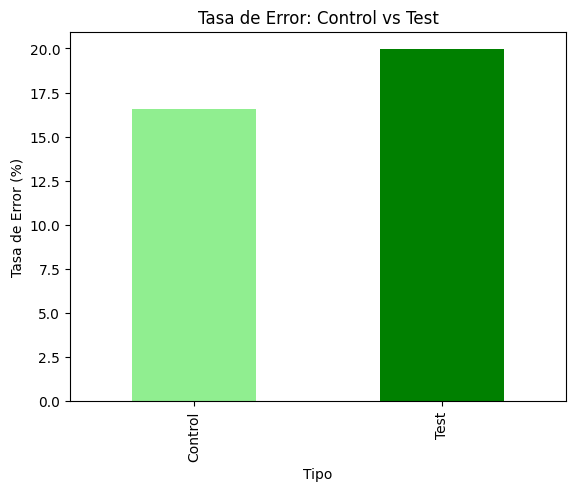

In [276]:
tabla_error["tasa_error"].plot(kind='bar', color=['lightgreen', 'green'])
plt.title('Tasa de Error: Control vs Test')
plt.ylabel('Tasa de Error (%)')
plt.xlabel('Tipo')
plt.show()

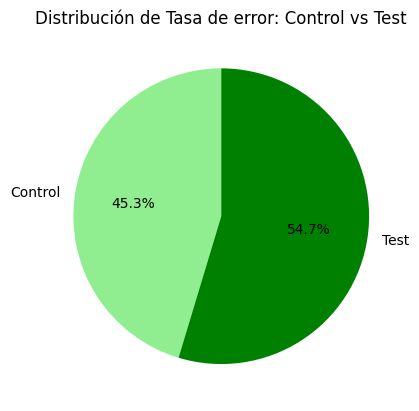

In [277]:
tabla_error["tasa_error"].plot(
    kind='pie', 
    colors=['lightgreen', 'green'], 
    autopct='%1.1f%%', 
    startangle=90,
    ylabel=''
)

plt.title('Distribución de Tasa de error: Control vs Test')
plt.show()

### Tasa de éxito por edad

In [278]:
## Asumimos que el éxito del proceso es el conjunto de todos los usuarios que han confirmado el proceso.

In [279]:
## Es decir, de esos 17330 (control) y 25594 (test) (total: 42924), ¿qué edad tienen? 
clientes_proceso

paso,confirm,start,step_1,step_2,step_3
tipo,,,,,
Control,17330,45366,29535,25766,22497
Test,25594,55753,38651,30888,25755


In [280]:
## La tasa sería entonces la cantidad de usuarios que confirmaron, entre el total de todos los usuarios que iniciaron x 100 (para porcentaje)
df_final['confirmacion'] = (df_final['paso'] == 'confirm')
df_final['confirmacion']

300422     True
300421     True
76866     False
76865     False
76864     False
          ...  
196202    False
196201    False
196200    False
196199    False
196198    False
Name: confirmacion, Length: 317135, dtype: bool

In [281]:
df_final['confirmacion'].value_counts()

confirmacion
False    274211
True      42924
Name: count, dtype: int64

In [282]:
df_final_edad = f.rango_edad(df_final, 'edad')

In [283]:
df_final_edad

,client_id,años_fidelizacion,meses_fidelizacion,edad,genero,cantidad_cuentas,saldo_total_distribuido,llamadas_ultimos_6meses,log_in_ultimos_6meses,tipo,...,visit_id,paso,fecha_y_hora,fecha,hora,grupo_hora,tiempo_visita,segundos_visita,confirmacion,grupo_edad
300422,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,...,100012776_37918976071_457913,confirm,2017-04-26 13:22:17,2017-04-26,13:22:17,Mediodía(12-18),NaT,0.0,True,Adultos maduros(51-65)
300421,3561384,4.0,56.0,59.5,U,2.0,63130.44,6.0,9.0,Test,...,100012776_37918976071_457913,confirm,2017-04-26 13:23:09,2017-04-26,13:23:09,Mediodía(12-18),0 days 00:00:52,52.0,True,Adultos maduros(51-65)
76866,7338123,7.0,88.0,23.5,M,2.0,26436.73,6.0,9.0,Test,...,100019538_17884295066_43909,start,2017-04-09 16:20:56,2017-04-09,16:20:56,Mediodía(12-18),NaT,0.0,False,Jóvenes(19-35)
76865,7338123,7.0,88.0,23.5,M,2.0,26436.73,6.0,9.0,Test,...,100019538_17884295066_43909,step_1,2017-04-09 16:21:12,2017-04-09,16:21:12,Mediodía(12-18),0 days 00:00:16,16.0,False,Jóvenes(19-35)
76864,7338123,7.0,88.0,23.5,M,2.0,26436.73,6.0,9.0,Test,...,100019538_17884295066_43909,step_2,2017-04-09 16:21:21,2017-04-09,16:21:21,Mediodía(12-18),0 days 00:00:09,9.0,False,Jóvenes(19-35)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196202,6627522,18.0,227.0,58.0,F,2.0,1056775.54,6.0,9.0,Test,...,999988789_76411676596_272843,start,2017-04-21 23:49:11,2017-04-21,23:49:11,Tarde(18-24),NaT,0.0,False,Adultos maduros(51-65)
196201,6627522,18.0,227.0,58.0,F,2.0,1056775.54,6.0,9.0,Test,...,999988789_76411676596_272843,step_1,2017-04-21 23:49:22,2017-04-21,23:49:22,Tarde(18-24),0 days 00:00:11,11.0,False,Adultos maduros(51-65)
196200,6627522,18.0,227.0,58.0,F,2.0,1056775.54,6.0,9.0,Test,...,999988789_76411676596_272843,step_2,2017-04-21 23:50:16,2017-04-21,23:50:16,Tarde(18-24),0 days 00:00:54,54.0,False,Adultos maduros(51-65)
196199,6627522,18.0,227.0,58.0,F,2.0,1056775.54,6.0,9.0,Test,...,999988789_76411676596_272843,step_1,2017-04-21 23:51:00,2017-04-21,23:51:00,Tarde(18-24),0 days 00:00:44,44.0,False,Adultos maduros(51-65)


In [284]:
tasa_exito = df_final_edad.groupby('grupo_edad')['confirmacion']

/var/folders/bk/hzstscb16rn4p883jsg8t31c0000gn/T/ipykernel_2800/2213165048.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa_exito = df_final_edad.groupby('grupo_edad')['confirmacion']


In [285]:
tasa_exito.value_counts()

grupo_edad              confirmacion
Niños(0-18)             False             635
                        True              109
Jóvenes(19-35)          False           69985
                        True            11459
Adultos(36-50)          False           66520
                        True            10864
Adultos maduros(51-65)  False           94361
                        True            14166
Adultos mayores(66+)    False           42710
                        True             6326
Name: count, dtype: int64

In [286]:
df_final.columns

Index(['client_id', 'años_fidelizacion', 'meses_fidelizacion', 'edad',
       'genero', 'cantidad_cuentas', 'saldo_total_distribuido',
       'llamadas_ultimos_6meses', 'log_in_ultimos_6meses', 'tipo',
       'visitor_id', 'visit_id', 'paso', 'fecha_y_hora', 'fecha', 'hora',
       'grupo_hora', 'tiempo_visita', 'segundos_visita', 'confirmacion'],
      dtype='object')

In [287]:
## Agrupamos por edad y calculamos la media de los valores True
tasa_por_edad = df_final_edad.groupby('grupo_edad')['confirmacion'].mean() * 100

/var/folders/bk/hzstscb16rn4p883jsg8t31c0000gn/T/ipykernel_2800/770117500.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa_por_edad = df_final_edad.groupby('grupo_edad')['confirmacion'].mean() * 100


In [288]:
df_tasa = tasa_por_edad.reset_index()
df_tasa.columns = ['grupo_edad', 'porcentaje_confirmacion']

In [289]:
df_tasa

,grupo_edad,porcentaje_confirmacion
0,Niños(0-18),14.650538
1,Jóvenes(19-35),14.069790
2,Adultos(36-50),14.039078
3,Adultos maduros(51-65),13.052973
4,Adultos mayores(66+),12.900726


/var/folders/bk/hzstscb16rn4p883jsg8t31c0000gn/T/ipykernel_2800/3950623530.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tasa, x='grupo_edad', y='porcentaje_confirmacion', palette='viridis')


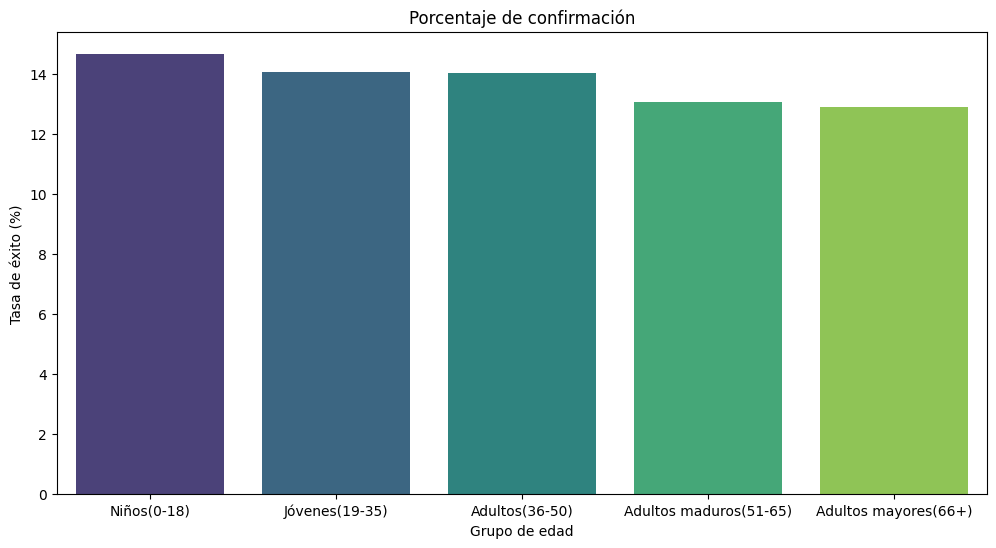

In [290]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_tasa, x='grupo_edad', y='porcentaje_confirmacion', palette='viridis')
plt.title('Porcentaje de confirmación')
plt.ylabel('Tasa de éxito (%)')
plt.xlabel('Grupo de edad')
plt.show()

#### Tasa de éxito por edad y grupo Control o Test

In [291]:
tasa_grupo_edad = df_final_edad.groupby(['grupo_edad', 'tipo'])['confirmacion'].mean().reset_index()

/var/folders/bk/hzstscb16rn4p883jsg8t31c0000gn/T/ipykernel_2800/2919206548.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa_grupo_edad = df_final_edad.groupby(['grupo_edad', 'tipo'])['confirmacion'].mean().reset_index()


In [292]:
## Obtengo porcentaje
tasa_grupo_edad['confirmacion'] *= 100

In [293]:
# Renombramos en la tabla
tasa_grupo_edad.columns = ['Grupo de Edad', 'Segmento', 'Tasa de Éxito (%)']
tasa_grupo_edad

,Grupo de Edad,Segmento,Tasa de Éxito (%)
0,Niños(0-18),Control,14.285714
1,Niños(0-18),Test,15.000000
2,Jóvenes(19-35),Control,12.538852
3,Jóvenes(19-35),Test,15.324130
4,Adultos(36-50),Control,12.808150
5,Adultos(36-50),Test,15.047368
6,Adultos maduros(51-65),Control,12.264191
7,Adultos maduros(51-65),Test,13.661970
8,Adultos mayores(66+),Control,11.335178
9,Adultos mayores(66+),Test,14.105294


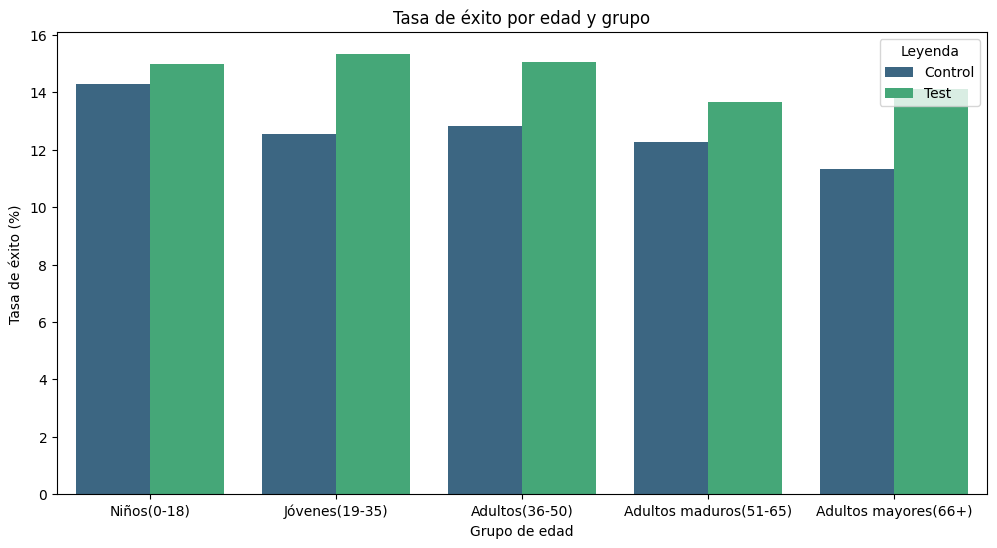

In [294]:
plt.figure(figsize=(12, 6))
sns.barplot(data=tasa_grupo_edad, x='Grupo de Edad', y='Tasa de Éxito (%)', hue='Segmento', palette='viridis')
plt.title('Tasa de éxito por edad y grupo')
plt.ylabel('Tasa de éxito (%)')
plt.xlabel('Grupo de edad')
plt.legend(title='Leyenda')

### Tiempo promedio dedicado en cada grupo

In [295]:
## Agrupamos por tipo y segundos y calculamos la media de los valores True
tiempo_grupo = df_final.groupby('tipo')['segundos_visita'].mean()

In [296]:
tiempo_grupo

tipo
Control    64.779208
Test       66.692806
Name: segundos_visita, dtype: float64

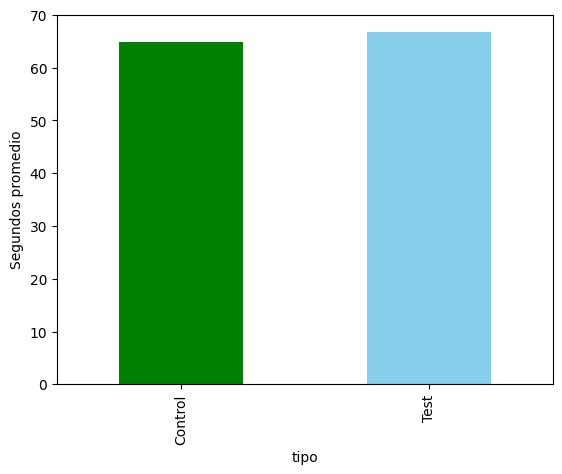

In [297]:
tiempo_grupo.plot(kind='bar', color=['green', 'skyblue'])
plt.ylabel('Segundos promedio')
plt.show()

## RESPUESTA: 
# En función de los KPI elegidos, ¿cómo se compara el rendimiento del nuevo diseño con el anterior? 

### 1. Tasa de finalización
* H0: tasa finalización de test == tasa de finalización de control
* H1: tasa finalización de test > tasa de finalización de control

In [298]:
## Extraemos los datos de análisis que es la finalización. 
# Considerando que terminaron y comenzaron en el mismo día.

In [299]:
# Convertimos la columna a enteros (True -> 1, False -> 0) para poder contarlos
pasos_por_dia['completo_mismo_dia'] = pasos_por_dia['completo_mismo_dia'].astype(int)
pasos_por_dia['hizo_start'] = pasos_por_dia['hizo_start'].astype(int)

# Separamos los grupos para testear normalidad en cada uno
control_grupo = pasos_por_dia[pasos_por_dia['tipo'] == 'Control']['completo_mismo_dia']
test_grupo = pasos_por_dia[pasos_por_dia['tipo'] == 'Test']['completo_mismo_dia']

In [300]:
analisis=tabla_final[["total_inicios_unicos","completados_mismo_dia"]]

In [301]:
from scipy.stats import chi2_contingency
chi2_statistic, chi2_p_value, _, _ = chi2_contingency(analisis)

chi2_statistic, chi2_p_value

(np.float64(139.90217271756435), np.float64(2.796445504818248e-32))

In [302]:
## No hay evidencia estadística de relación.
# Veremos si la muestra proviene de una distribución normal
# -  Tenemos una muestra grande (> 5000) así que usaremos el test de Kolmogorov-Smirnov

In [303]:
def check_normality(pasos_por_dia, group_name):
    stat, p_value = stats.kstest(pasos_por_dia, 'norm')
    
    print(f"--- Grupo {group_name} ---")
    print(f"Estadístico D: {stat}")
    print(f"P-valor: {p_value}")
    
    if p_value < 0.05:
        print("Resultado: La muestra No proviene de la ditribución teórica (Rechazamos H0)")
    else:
        print("Resultado: Los muestra proviene de la ditribución teórica (No rechazamos H0)")
    print("-" * 30)

In [304]:
# Ejecutamos para ambos nuestra función de normalidad
check_normality(control_grupo, "Control")
check_normality(test_grupo, "Test")

--- Grupo Control ---
Estadístico D: 0.5
P-valor: 0.0
Resultado: La muestra No proviene de la ditribución teórica (Rechazamos H0)
------------------------------
--- Grupo Test ---
Estadístico D: 0.5
P-valor: 0.0
Resultado: La muestra No proviene de la ditribución teórica (Rechazamos H0)
------------------------------


In [305]:
# Pero por el Teorema del Límite Central que dice si tu muestra es grande (usualmente), la distribución de la proporción se aproxima a una normal, lo que nos permite usar el T-Test ya que comparamos medidas entre dos grupos.

In [306]:
# Nivel de significancia
alpha = 0.05

In [307]:
resultado = stats.ttest_ind(test_grupo, control_grupo, equal_var=False)

In [309]:

# Para mostrar los resultados
print(f'Tasa Control: {sum(control_grupo)/len(control_grupo):.2%}')
print(f'Tasa Test: {sum(test_grupo)/len(test_grupo):.2%}')
print("-" * 30)
print(f'Estadístico t: {resultado.statistic}')
print(f'p-value: {resultado.pvalue}')
print("-" * 30)

# Interpretación
if resultado.pvalue < alpha:
    print("Resultado: Hay una diferencia significativa entre las tasas de finalización.")
    print("Interpretación: El nuevo diseño (Test) tiene un impacto real en el comportamiento.")
else:
    print("Resultado: No hay una diferencia significativa.")
    print("Interpretación: La diferencia observada podría deberse al azar.")

Tasa Control: 52.13%
Tasa Test: 60.80%
------------------------------
Estadístico t: 22.533683165129244
p-value: 5.262446423067355e-112
------------------------------
Resultado: Hay una diferencia significativa entre las tasas de finalización.
Interpretación: El nuevo diseño (Test) tiene un impacto real en el comportamiento.


### 2. Tasa de finalización con un umbral de costo-efectividad
Prueba A/B 
La tasa de finalización de test es por lo menos un 5% mayor que la de control. 
* H0: El aumento en la tasa de finalización es ≤5%.
* H1: El aumento en la tasa de finalización es >5%.

In [ ]:
# Como ya sabemos que aplicamos el teorema del limite central que dice que si la muestra es grande podemos usar T-Test 

In [ ]:
grupo_control = df_final[df_final['tipo'] == 'Control']['confirmacion']
grupo_test = df_final[df_final['tipo'] == 'Test']['confirmacion']

In [ ]:
umbral = 0.05
alpha = 0.05

In [ ]:
t_stat, p_value = stats.ttest_ind(grupo_test - umbral, grupo_control, alternative='greater')

In [ ]:
p_value

np.float64(1.0)

In [ ]:
tasa_control = grupo_control.mean()
tasa_test = grupo_test.mean()
diferencia_real = tasa_test - tasa_control

In [ ]:
print(f'Tasa finalización control: {tasa_control:.2%}')
print(f'Tasa finalización test: {tasa_test:.2%}')

Tasa finalización control: 12.34%
Tasa finalización test: 14.49%


In [ ]:
print(f"Mejora: {diferencia_real:.2%}")

Mejora: 2.15%


In [ ]:
# El nuevo diseño NO es justificable económicamente porque aunque haya mejora, no hay evidencia suficiente de que supere el 5%.

### 3. ¿Hay relación entre la fidelización y el tiempo de visita?
* H0 : No existe relación entre años de fidelización y segundos de visita 
* H1: Existe relación entre años de fidelización y segundos de visita  

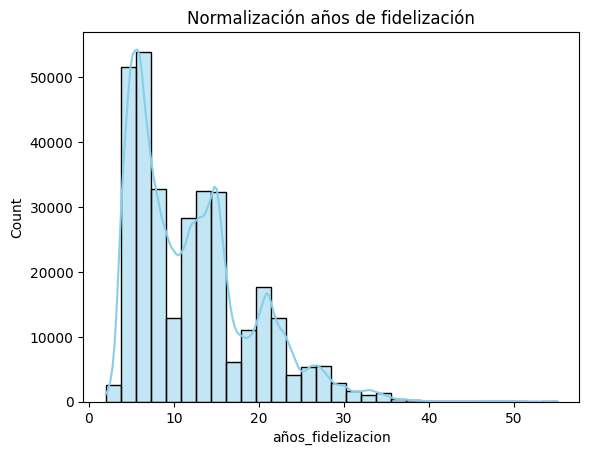

In [ ]:
## Comprobamos valores normales de 'años de fidelización' y los valores normales de 'segundos visita'
sns.histplot(df_final['años_fidelizacion'], kde=True, bins=30, color="skyblue")
plt.title('Normalización años de fidelización')
plt.show()

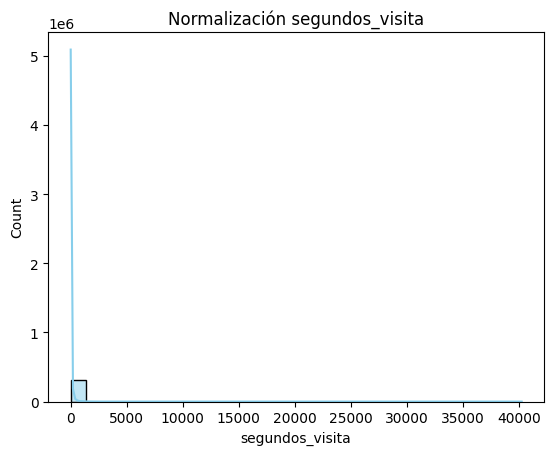

In [ ]:
sns.histplot(df_final['segundos_visita'], kde=True, bins=30, color="skyblue")
plt.title('Normalización segundos_visita')
plt.show()

In [ ]:
## Aunque a simple vista vemos cómo los datos no son normales, lo comprobamos con el coeficiente Spearman.
correlacion = df_final['años_fidelizacion'].corr(df_final['segundos_visita'], method='spearman')
correlacion

np.float64(0.02030572675350489)

In [ ]:
## Parece que existe una correlación muy débil entre ambas columnas porque parece que, por lo menos, no se mueven juntas. Pero para demostrarlo, hacemos un Mann-Withney U

In [ ]:
## Dividimos la columna en dos grupos: nuevos y antiguos clientes basándonos en la mediana (porque los datos no son normales): 
años_mediana = df_final['años_fidelizacion'].median()

In [ ]:
nuevos = df_final.loc[df_final['años_fidelizacion']<= años_mediana, 'segundos_visita'].dropna()
antiguos = df_final.loc[df_final['años_fidelizacion'] > años_mediana, 'segundos_visita'].dropna()

In [ ]:
alpha = 0.05

In [ ]:
stat, p_value = mannwhitneyu(nuevos, antiguos)
p_value

np.float64(9.13381003120267e-21)

In [ ]:
## Como el p-valor es menor que alpha, rechazamos la H0. Esto significa que, estadísticamente, el tiempo que pasan en la visita sí cambia dependiendo de si el cliente es "nuevo" o "antiguo", a pesar de que la correlación general sea baja.

### 4. Los clientes que llaman más al soporte son más lentos navegando en la web que los que no llaman. 
* H0 : No hay diferencia en el promedio de segundos_visita entre los clientes con alta frecuencia de llamadas (llamadas_ultimos_6meses > p75) y los de baja frecuencia.
* H1: Los clientes con más llamadas tienen un promedio de segundos_visita significativamente mayor (indicando posible dificultad de uso).

Text(0.5, 1.0, 'Outliers')

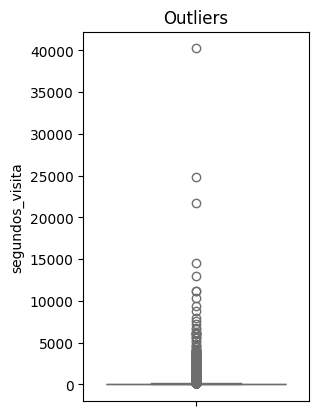

In [ ]:
## Los datos no son normales, tienen outliers muy extremos. 
plt.subplot(1, 2, 2)
sns.boxplot(y=df_final['segundos_visita'], color='lightcoral')
plt.title('Outliers')

In [ ]:
## Para quedarnos con el comportamiento estándar del usuario usamos IQR
Q1 = df_final['segundos_visita'].quantile(0.25)
Q3 = df_final['segundos_visita'].quantile(0.75)
IQR = Q3 - Q1

In [ ]:
df_final_no_outliers = df_final[df_final['segundos_visita'] <= (Q3 + 1.5 * IQR)]

Text(0.5, 1.0, 'Outliers limpios')

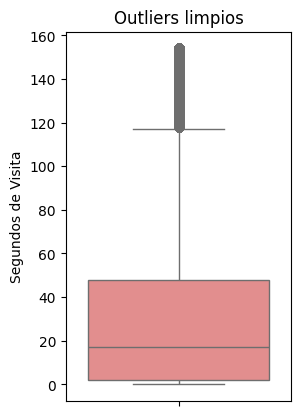

In [ ]:
## Comprobamos que ya no hay outliers 
plt.subplot(1, 2, 2)
sns.boxplot(y=df_final_no_outliers['segundos_visita'], color='lightcoral')
plt.ylabel('Segundos de Visita')
plt.title('Outliers limpios')

In [ ]:
## Necesito este df limpio, junto a llamadas
df_hipotesis = df_final_no_outliers.dropna(subset=['segundos_visita', 'llamadas_ultimos_6meses'])

In [ ]:
## Nuestra mayoría de clientes lo definiremos por las llamadas del percentil mayor
percentil_mayor = df_hipotesis['llamadas_ultimos_6meses'].quantile(0.75)
percentil_mayor

np.float64(6.0)

In [ ]:
muchas_llamadas = df_hipotesis[df_hipotesis['llamadas_ultimos_6meses'] >= 6]['segundos_visita'].dropna()
pocas_llamadas = df_hipotesis[df_hipotesis['llamadas_ultimos_6meses'] < 6]['segundos_visita'].dropna()

In [ ]:
alpha = 0.05

In [ ]:
## Creo que es mejor usar un Mann-Withney porque nos basamos en la mediana, no en la media (porque es más baja)
stat, p_value = mannwhitneyu(muchas_llamadas, pocas_llamadas)

In [ ]:
p_value

np.float64(2.0543373009674772e-20)

In [ ]:
## Como el p-value es mucho menor, rechazamos de lleno la H0 y aceptamos la contraria, es decir, que hay evidencia estadísitca de que el tiempo de visita es diferente según si se llama más o menos.

### 5. ¿El género influye en la cantidad de dinero?
* H0: La media de cantidad_cuentas es igual para todos los grupos de género.
* H1: Existe una diferencia significativa en la cantidad_cuentas según el género.

In [ ]:
## Comprobamos la  normalidad de los valores
normalidad = stat, p_val = stats.normaltest(df_final['cantidad_cuentas'])
normalidad

NormaltestResult(statistic=np.float64(146591.7459043496), pvalue=np.float64(0.0))

In [ ]:
## Media de cuentas por género
df_hipotesis_genero = df_final.groupby('genero')['cantidad_cuentas'].mean()
df_hipotesis_genero

genero
F    2.230620
M    2.343196
U    2.211757
X    2.000000
Name: cantidad_cuentas, dtype: float64

In [ ]:
## Agrupamos por géneros 
mujeres = df_final[df_final['genero'] == 'F']['cantidad_cuentas']
hombres = df_final[df_final['genero'] == 'M']['cantidad_cuentas']
otros = df_final[df_final['genero'].isin(['U', 'X'])]['cantidad_cuentas']

In [ ]:
alpha = 0.05

In [ ]:
## Como los datos no son normales, en lugar de usar ANOVA, usamos Kruskal-Wallis
resultado = stat, p_final = stats.kruskal(mujeres, hombres, otros)
resultado

KruskalResult(statistic=np.float64(3532.4066752652907), pvalue=np.float64(0.0))

In [ ]:
## Como es menor que 0.05 rechazamos la hipótesis nula, es decir, que existe una diferencia en la cantidad de cuentas según el género. 

### ¿Hay sesgos?

In [ ]:
perfil_test['participacion'] = perfil_test['total_clientes'] / perfil_test['total_clientes'].sum()
perfil_control['participacion'] = perfil_control['total_clientes'] / perfil_control['total_clientes'].sum()

In [ ]:
perfil_test

,años_fidelizacion,log_in_ultimos_6meses,edad,total_clientes,grupo,participacion
genero,,,,,,
F,14.89809,5.997714,51.775104,8716,Test,0.323282
M,14.96323,6.586982,50.730030,8977,Test,0.332962
U,6.72597,6.136745,43.711555,9266,Test,0.343682
X,10.25000,7.125000,34.750000,2,Test,0.000074


In [ ]:
perfil_control

,años_fidelizacion,log_in_ultimos_6meses,edad,total_clientes,grupo,participacion
genero,,,,,,
F,14.927018,6.011559,51.440712,7543,Control,0.32061
M,15.131878,6.647432,50.727628,7970,Control,0.33876
U,6.722346,6.236219,42.983649,8014,Control,0.34063


In [ ]:
perfil_uso['participacion'] = perfil_uso['total_clientes'] / perfil_uso['total_clientes'].sum()
perfil_uso

,años_fidelizacion,log_in_ultimos_6meses,edad,total_clientes,participacion
genero,,,,,
F,14.0,5.0,51.0,22746,0.322204
M,14.0,6.0,49.5,23724,0.336058
U,6.0,5.0,39.0,24122,0.341696
X,9.0,5.0,40.0,3,0.000042


In [ ]:
## Veamos un T- test para ver si hay sesgos
df_unicos = df_final.drop_duplicates(subset=['client_id'])

test_f = df_unicos[(df_unicos['tipo'] == 'Test')]["edad"]
control_f = df_unicos[(df_unicos['tipo'] == 'Control')]["edad"]

t_stat, p_val = stats.ttest_ind(control_f, test_f)

print(f"P-valor: {p_val}")
if p_val > 0.05:
    print("No hay sesgo significativo: Los grupos son comparables.(Son iguales)")
else:
    print("Ojo: Hay una diferencia significativa entre las muestras.(Son diferentes)")


P-valor: 0.015701079231227627
Ojo: Hay una diferencia significativa entre las muestras.(Son diferentes)


# Evaluación del experimento
También deberá realizar una evaluación del experimento respondiendo preguntas sobre la efectividad del diseño, la duración y cualquier necesidad de datos adicionales. Consulte los detalles completos a continuación:

#### Eficacia del diseño 

**¿El experimento estuvo bien estructurado? ¿Los clientes se dividieron aleatoriamente y en partes iguales entre los diseños antiguos y los nuevos? ¿Hubo algún sesgo?**


El análisis valida que la estructura permitió comparar métricas críticas como la tasa de finalización y el tiempo de permanencia mediante pruebas estadísticas como la de t de Student y Mann-Whitney U.
Se procesaron datos de más de 70,000 perfiles, asegurando una base sólida para la comparación entre ambos diseños. El muestreo de ambos grupos parece equilibrado (el de control un 47% y el de test 53%), aunque con una ligera inclinación hacia el grupo de test. Tanto la fidelidad como la edad parece equilibrada (medias similares entre ambos grupos) y de manera similar ocurre con las columna de género. Es cierto que con hay en el grupo de test un muestreo de género X que no está en el de Control, pero realmente son solo dos registros, por los que validamos que las muestras, aun con sus diferencias, no han sido toamdas con sesgos. 


#### Evaluación de la duración

**¿El período de tiempo del experimento (del 15/3/2017 al 20/6/2017) fue adecuado para recopilar datos y conocimientos significativos?**

El experimento se llevó a cabo del 15/3/2017 al 20/6/2017. Este marco temporal de tres meses se considera adecuado para capturar el comportamiento natural del usuario y obtener una muestra estadísticamente significativa de interacciones con la nueva interfaz.


#### Necesidades de datos adicionales 

**¿Qué otros datos, si estuvieran disponibles, podrían mejorar el análisis?** 

El nivel de satisfacción del usuario respecto a su comportamiento dentro de la plaltaforma, identificar cuáles son los patrones de abandono de los pasos del proceso y/o con subgrupos dentro de test y control diferenciados por edad o género podríamos acotar a quién le sirve más o menos la nueva interfaz. 


#### Resultados clave y comportamiento del cliente 

**Perfil**
    
    Los principales usuarios del sistema tienen una edad promedio de 46.4 años y una antigüedad de 12 años en la empresa. Los grupos de género masculino y femenino son los más veteranos, con una mediana de fidelización de 14 años, mientras que el grupo desconocido es más reciente, con una mediana de 6 años

**Engagement**
    
    Los hombres mostraron una actividad ligeramente superior con una mediana de 6 inicios de sesión en los últimos 6 meses, frente a los 5 inicios de sesión de las mujeres y el grupo de género desconocido. Los grupos femenino y desconocido mantienen una actividad constante con una mediana de 5 inicios de sesión en el mismo periodo

**Promedios**
    
    El promedio de cuentas por cliente es de 2.25, con un saldo total distribuido medio significativo, lo que indica que el proceso en línea es crítico para usuarios con activos considerables.


**Diferencia entre grupos**
    
    El análisis concluye que hay una diferencia significativa entre las muestras del grupo de Control y Test, lo que indica que el cambio de diseño sí impactó de forma medible el comportamiento de los usuarios, pero no respecto a la expectativa de Vanguard.